# Multi-Modal Public Transport Demand Forecasting

### Authored by: Siddhi Krishna Dabhade

**Duration:** 110 mins                                 
                       **Level:** Intermediate                                       
                       **Pre-requisite Skills:** Python, Pandas, Data Cleaning, Data Visualisation

### Project Overview

This project focuses on developing a multi-modal public transport demand forecasting system capable of predicting passenger demand across different transport modes and cities using real-world public datasets. The system was designed to forecast transport demand trends and support better planning and scheduling decisions for urban mobility systems.

The project addresses a major gap in traditional transport forecasting approaches, where buses, trains and trams are often analysed independently rather than as interconnected transport systems.

A high-demand classification layer to support dynamic scheduling decisions was introduced where historical demand thresholds are used to identify peak demand periods. This allows the system to flag periods where additional transport services may be required, supporting more adaptive and efficient public transport planning.

---

### Problem Statement

Most transport demand forecasting systems treat each transport mode separately, which limits the ability to understand interactions between urban transport networks. In real-world cities, transport modes influence one another and passenger demand patterns are highly dependent on temporal and behavioural factors.

The project aimed to solve this issue by creating a unified forecasting framework capable of analysing multiple transport modes and cities together.

---

### Datasets Used

The project integrates multiple real-world public transport datasets from different cities and transport authorities, including:

1. London TfL journeys by transport type  
2. NYC MTA ridership  
3. Melbourne monthly public transport patronage by mode  
4. Victorian monthly average patronage by day type and mode  
5. NSW all-modes patronage 

The datasets were accessed using APIs, enabling the development of a realistic and scalable transport forecasting pipeline.

---

### Data Collection and Integration

A significant portion of the project involved collecting, cleaning and integrating datasets from different sources. Each dataset contained different structures, date formats, transport mode naming conventions and reporting styles.

To address this, a unified schema was developed containing:

- Date  
- City  
- Transport mode  
- Passenger demand  
- Source dataset  

Additional preprocessing tasks included:

- Handling missing values  
- Removing unnecessary columns  
- Cleaning formatting inconsistencies  
- Standardising timestamps and dates  
- Converting wide-format datasets into long-format time-series datasets  
- Aligning overlapping date ranges across all cities  

This created a consolidated dataset suitable for forecasting and comparative analysis.

---

### Feature Engineering

Feature engineering was performed to improve predictive performance and capture temporal transport demand behaviour.

The following features were developed:

##### Temporal Features
- Month  
- Quarter  
- Seasonal indicators  
- Cyclical month features using sine and cosine transformations  

##### Lag Features
- Previous month demand  
- Two-month lag demand  
- Three-month lag demand  

##### Rolling Statistics
- Three-month rolling averages  
- Six-month rolling averages  

##### Additional Behavioural Features

The Victorian day-type patronage dataset was used to generate:

- Average daily patronage  
- Maximum daily patronage  
- Minimum daily patronage  

These features provided additional insight into transport demand behaviour and seasonal mobility trends.

---

### Forecasting Model

The main forecasting model used in the project was a Random Forest regression model.

A complete machine learning pipeline was developed using:

- Feature preprocessing  
- Missing value imputation  
- Categorical encoding  
- Time-series-aware train-test splitting  

The model was trained to forecast passenger demand across multiple transport modes and cities simultaneously.

---

### Model Evaluation

The forecasting model was evaluated using multiple regression metrics, including:

- Mean Absolute Error (MAE)  
- Root Mean Squared Error (RMSE)  
- Mean Absolute Percentage Error (MAPE)  

These metrics helped assess the model’s forecasting accuracy and compare predictions across different transport systems.

---

### Model Optimisation

To improve forecasting performance, hyperparameter tuning was implemented using:

- GridSearchCV  
- TimeSeriesSplit cross-validation  

which ensured that temporal ordering was preserved while optimising model parameters.

Feature importance analysis was also performed to identify the strongest drivers of transport demand, including:

- Lagged demand patterns  
- Seasonal trends  
- Daily patronage indicators  

---

### Experimental LSTM (Long Short-Term Memory) model 

The LSTM model was designed to:

- Capture sequential temporal dependencies  
- Learn demand patterns over time  
- Forecast future transport demand using sequential data  

Although the datasets were relatively small for deep learning applications, the LSTM component demonstrated the integration of neural network-based forecasting within the transport demand pipeline.

---

### Visualisation and Interpretation

Several visualisations were developed to improve interpretability and communicate forecasting results effectively.

These included:

- Actual vs predicted demand plots  
- Cross-mode demand comparisons  
- Trend analysis visualisations  
- Demand forecasting outputs for each city and transport mode  

---

Thus the end-to-end multi-modal transport demand forecasting pipeline capable of:

- Loading real-world transport datasets  
- Standardising and integrating multi-city transport data  
- Engineering temporal forecasting features  
- Training machine learning and deep learning models  
- Forecasting transport demand trends  
- Supporting dynamic scheduling and transport planning  

The project demonstrates the practical application of urban mobility analytics, time-series forecasting and transport demand modelling using real-world public datasets.

# Importing Required Libraries

This section imports all packages needed for data loading, data cleaning, time-series feature engineering, modelling, evaluation, visualisation and experimental LSTM modelling

In [1]:
# Suppressing unnecessary warnings 
import warnings
warnings.filterwarnings("ignore")

# Core Python/data science libraries
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Used to convert HTTP response text into a file-like object for pandas
from io import StringIO

# Scikit-learn tools for preprocessing, modelling and evaluation
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Tensorflow for LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# Dataset Loading Helpers

Since the datasets come from several different public sources and the URLs behave differently depending on how they are accessed, the helper fucntions help us access and read them.

**load_dataset()** is a function sends a browser-like request header to reduce access errors, reads a direct CSV URL into a dataframe, checks whether the response is actually CSV rather than an HTML page and raises an error if the dataset is empty. Some public data servers block default Python/pandas requests. Thus, it uses browser-like request headers and validates that a real CSV file is returned.

**get_ckan_resource_download_url()** is a fucntion where Victorian day-type dataset is identified by a CKAN resource ID. This helper converts the resource ID into the actual downloadable file URL.


In [2]:
def load_dataset(dataset_name, url, timeout=60):

    # Browser-like headers reduce the chance of 403 Forbidden responses.
    headers = {
        "User-Agent": "Mozilla/5.0",
        "Accept": "text/csv,text/plain,*/*"
    }

    print("\n" + "=" * 70)
    print(f"LOADING DATASET: {dataset_name}")
    print("=" * 70)

    # Send request to the dataset URL.
    response = requests.get(url, headers=headers, timeout=timeout)

    print("Status:", response.status_code)

    # Stop immediately if the request failed.
    response.raise_for_status()

    # Check if the URL returned a webpage instead of a CSV file.
    preview = response.text[:300].lower()

    if "<html" in preview or "<!doctype html" in preview:
        raise ValueError(
            f"{dataset_name} returned an HTML page instead of CSV. "
            "Check that the URL is the direct download URL."
        )

    # Convert response text into a dataframe.
    df = pd.read_csv(StringIO(response.text))

    # Stop if the dataframe is empty, because missing data would invalidate the project.
    if df.empty:
        raise ValueError(f"{dataset_name} loaded but returned an empty dataframe.")

    print(f"{dataset_name} loaded successfully.")
    print("Shape:", df.shape)

    return df


def get_ckan_resource_download_url(resource_id):
    """
    Convert an Open Data Victoria CKAN resource ID into a direct download URL.

    Parameters
    ----------
    resource_id : str
        CKAN resource identifier.

    Returns
    -------
    str
        Direct downloadable file URL.

    Why this is needed
    ------------------
    Some public data portals provide a resource page URL rather than a direct CSV.
    Pandas cannot read a webpage as a CSV. This helper uses the CKAN API to find
    the real download URL.
    """

    api_url = "https://opendata.transport.vic.gov.au/api/3/action/resource_show"

    headers = {
        "User-Agent": "Mozilla/5.0",
        "Accept": "application/json"
    }

    response = requests.get(api_url, params={"id": resource_id}, headers=headers, timeout=60)

    print("Resource show status:", response.status_code)

    response.raise_for_status()

    data = response.json()

    if not data.get("success", False):
        raise ValueError(f"resource_show failed for resource_id={resource_id}")

    download_url = data["result"].get("url")

    if not download_url:
        raise ValueError(f"No download URL found for resource_id={resource_id}")

    return download_url


# Dataset URLs

In [3]:
# Dataset 1: London TfL journeys by transport type.
LONDON_URL = "https://data.london.gov.uk/download/ep8ow/06a805f6-77c6-481a-8b08-ddef56afffdd/tfl-journeys-type.csv"

# Dataset 2: NYC MTA ridership dataset from Plotly's public dataset repository.
NYC_URL = "https://raw.githubusercontent.com/plotly/datasets/master/MTA_Ridership_by_DATA_NY_GOV.csv"

# Dataset 3: Melbourne monthly public transport patronage by mode.
MELBOURNE_URL = "https://opendata.transport.vic.gov.au/dataset/1ab35aa9-f21d-4f00-939b-60dade427d45/resource/74174b02-76bc-4d10-ae7c-401d90ef033c/download/monthly_public_transport_patronage_by_mode.csv"

# Dataset 4: Victorian monthly average patronage by day type and mode.
# The Victorian day-type dataset uses a resource ID because its actual CSV download URL is resolved using the CKAN helper function.
VIC_DAYTYPE_RESOURCE_ID = "4c6b2e7b-4d5e-4b0d-8626-24c4db1de8fa"

# Dataset 5: NSW all-modes patronage dataset.
NSW_URL = "https://opendata.transport.nsw.gov.au/data/dataset/c92c0418-8678-4e39-9c34-70be8c35f7ef/resource/75df8157-3eab-4cf1-a877-86ce7c08af26/download/all-modes_legacy.csv"


# Loading All Datasets

This section loads each dataset into a raw dataframe. At this stage no major transformations are applied.


In [4]:
# Loading London TfL journeys
london_raw = load_dataset(
    dataset_name="London TfL Journeys",
    url=LONDON_URL
)

# Loading NYC MTA ridership
nyc_raw = load_dataset(
    dataset_name="NYC MTA Ridership",
    url=NYC_URL
)

# Loading Melbourne monthly public transport patronage
melbourne_raw = load_dataset(
    dataset_name="Melbourne Monthly Public Transport Patronage",
    url=MELBOURNE_URL
)

# Loading NSW all-modes patronage
nsw_raw = load_dataset(
    dataset_name="NSW All-Modes Patronage",
    url=NSW_URL
)

# Resolving and loading Victorian day-type patronage
# The resource ID is converted into a real CSV download URL first
VIC_DAYTYPE_DOWNLOAD_URL = get_ckan_resource_download_url(VIC_DAYTYPE_RESOURCE_ID)
vic_daytype_raw = load_dataset(
    dataset_name="Victorian Day-Type Patronage",
    url=VIC_DAYTYPE_DOWNLOAD_URL
)
print("Victorian day-type actual download URL:", VIC_DAYTYPE_DOWNLOAD_URL)



LOADING DATASET: London TfL Journeys
Status: 200
London TfL Journeys loaded successfully.
Shape: (209, 14)

LOADING DATASET: NYC MTA Ridership
Status: 200
NYC MTA Ridership loaded successfully.
Shape: (1705, 15)

LOADING DATASET: Melbourne Monthly Public Transport Patronage
Status: 200
Melbourne Monthly Public Transport Patronage loaded successfully.
Shape: (118, 16)

LOADING DATASET: NSW All-Modes Patronage
Status: 200
NSW All-Modes Patronage loaded successfully.
Shape: (5589, 4)
Resource show status: 200

LOADING DATASET: Victorian Day-Type Patronage
Status: 200
Victorian Day-Type Patronage loaded successfully.
Shape: (4380, 7)
Victorian day-type actual download URL: https://opendata.transport.vic.gov.au/dataset/c2ebbb89-0098-48b0-a5a4-4af219b8bb28/resource/4c6b2e7b-4d5e-4b0d-8626-24c4db1de8fa/download/monthly_average_patronage_by_day_type_and_by_mode.csv


# Inspecting Datasets

Before cleaning, inspecting the raw column names and first few rows to verify that the loaded data matches the expected structure.


In [5]:
print("London columns:")
print(london_raw.columns.tolist())

print("\nNYC columns:")
print(nyc_raw.columns.tolist())

print("\nMelbourne columns:")
print(melbourne_raw.columns.tolist())

print("\nVictorian day-type columns:")
print(vic_daytype_raw.columns.tolist())

print("\nNSW columns:")
print(nsw_raw.columns.tolist())

# Displaying sample rows for visual inspection.
display(london_raw.head())
display(nyc_raw.head())
display(melbourne_raw.head())
display(vic_daytype_raw.head())
display(nsw_raw.head())


London columns:
['Period and Financial year', 'Reporting Period', 'Days in period', 'Period beginning', 'Period ending', 'Bus journeys (m)', 'Underground journeys (m)', 'DLR Journeys (m)', 'Tram Journeys (m)', 'Overground Journeys (m)', 'London Cable Car Journeys (m)', 'TfL Rail Journeys (m)', 'Unnamed: 12', 'Unnamed: 13']

NYC columns:
['Date', 'Subways: Total Estimated Ridership', 'Subways: % of Comparable Pre-Pandemic Day', 'Buses: Total Estimated Ridership', 'Buses: % of Comparable Pre-Pandemic Day', 'LIRR: Total Estimated Ridership', 'LIRR: % of Comparable Pre-Pandemic Day', 'Metro-North: Total Estimated Ridership', 'Metro-North: % of Comparable Pre-Pandemic Day', 'Access-A-Ride: Total Scheduled Trips', 'Access-A-Ride: % of Comparable Pre-Pandemic Day', 'Bridges and Tunnels: Total Traffic', 'Bridges and Tunnels: % of Comparable Pre-Pandemic Day', 'Staten Island Railway: Total Estimated Ridership', 'Staten Island Railway: % of Comparable Pre-Pandemic Day']

Melbourne columns:
['ï»¿

,Period and Financial year,Reporting Period,Days in period,Period beginning,Period ending,Bus journeys (m),Underground journeys (m),DLR Journeys (m),Tram Journeys (m),Overground Journeys (m),London Cable Car Journeys (m),TfL Rail Journeys (m),Unnamed: 12,Unnamed: 13
0,01_10/11,1.0,31.0,01-Apr-10,01-May-10,189.1,90.5,6.3,2.3,NaN,NaN,NaN,NaN,NaN
1,02_10/11,2.0,28.0,02-May-10,29-May-10,181.6,84.5,5.8,2.2,NaN,NaN,NaN,NaN,NaN
2,03_10/11,3.0,28.0,30-May-10,26-Jun-10,175.9,84.3,5.8,2.1,NaN,NaN,NaN,NaN,NaN
3,04_10/11,4.0,28.0,27-Jun-10,24-Jul-10,183.4,86.5,6.1,2.1,NaN,NaN,NaN,NaN,NaN
4,05_10/11,5.0,28.0,25-Jul-10,21-Aug-10,160.4,82.9,5.8,2.0,NaN,NaN,NaN,NaN,NaN


,Date,Subways: Total Estimated Ridership,Subways: % of Comparable Pre-Pandemic Day,Buses: Total Estimated Ridership,Buses: % of Comparable Pre-Pandemic Day,LIRR: Total Estimated Ridership,LIRR: % of Comparable Pre-Pandemic Day,Metro-North: Total Estimated Ridership,Metro-North: % of Comparable Pre-Pandemic Day,Access-A-Ride: Total Scheduled Trips,Access-A-Ride: % of Comparable Pre-Pandemic Day,Bridges and Tunnels: Total Traffic,Bridges and Tunnels: % of Comparable Pre-Pandemic Day,Staten Island Railway: Total Estimated Ridership,Staten Island Railway: % of Comparable Pre-Pandemic Day
0,03/01/2020,2212965,97,984908,99,86790,100,55825,59,19922,113,786960,98,1636,52
1,03/02/2020,5329915,96,2209066,99,321569,103,180701,66,30338,102,874619,95,17140,107
2,03/03/2020,5481103,98,2228608,99,319727,102,190648,69,32767,110,882175,96,17453,109
3,03/04/2020,5498809,99,2177165,97,311662,99,192689,70,34297,115,905558,98,17136,107
4,03/05/2020,5496453,99,2244515,100,307597,98,194386,70,33209,112,929298,101,17203,108


,ï»¿Year,Month,Month name,Metropolitan train,Metropolitan tram,Metropolitan bus,Regional train,Regional coach,Regional bus,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,2018.0,1.0,January,"16,809,932","15,231,368","7,568,547","1,466,256","116,568","721,229",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018.0,2.0,February,"19,554,477","16,980,925","10,487,311","1,522,981","103,197","1,118,494",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018.0,3.0,March,"22,659,010","19,832,126","11,528,895","1,809,774","117,180","1,224,816",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018.0,4.0,April,"20,312,040","16,919,872","9,592,750","1,684,827","107,480","946,218",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018.0,5.0,May,"22,768,447","17,691,427","11,263,486","1,790,656","109,456","1,258,704",NaN,NaN,NaN,NaN,NaN,NaN,NaN


,ï»¿Year,Month,Month_name,Day_of_week,Day_type,Mode,Pax_daily
0,2018,1,Jan,Friday,School Holiday Weekday,MetroBus,268350
1,2018,1,Jan,Friday,School Holiday Weekday,MetroTrain,570700
2,2018,1,Jan,Friday,School Holiday Weekday,RegionalBus,21550
3,2018,1,Jan,Friday,School Holiday Weekday,RegionalTrain,43700
4,2018,1,Jan,Friday,School Holiday Weekday,Tram,529250


,Year_Month,Card Type,Travel_Mode,Trip
0,Feb-23,Adult,Bus,6556480
1,Jan-23,Employee,Bus,53044
2,Dec-22,Child/Youth,Bus,779633
3,Dec-22,Adult,Bus,6005060
4,Nov-22,Free Travel,Bus,29299


# Standardising the datasets

### 1. Standardising Melbourne Monthly Patronage

The Melbourne monthly dataset is in wide format, where each mode has its own column.

This section:

- removes hidden encoding characters from column names
- removes unused empty Unnamed columns
- standardises column names
- converts year/month into a proper date
- cleans comma-formatted demand values
- converts the data from wide format into long format


In [6]:
melbourne = melbourne_raw.copy()

# Removing hidden BOM characters and strip whitespace from column names
melbourne.columns = (
    melbourne.columns
    .str.replace("ï»¿", "", regex=False)
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)

# Dropping empty/unnecessary unnamed columns
melbourne = melbourne.loc[:, ~melbourne.columns.str.contains("^Unnamed")]

print("Melbourne columns after cleaning:")
print(melbourne.columns.tolist())

# Renaming columns into Python-friendly names
melbourne = melbourne.rename(columns={
    "Year": "year",
    "Month": "month",
    "Month name": "month_name",
    "Metropolitan train": "metro_train",
    "Metropolitan tram": "metro_tram",
    "Metropolitan bus": "metro_bus",
    "Regional train": "regional_train",
    "Regional coach": "regional_coach",
    "Regional bus": "regional_bus"
})

print("Melbourne columns after renaming:")
print(melbourne.columns.tolist())

# Defining the mode columns that will become rows in long format
melbourne_modes = [
    "metro_train",
    "metro_tram",
    "metro_bus",
    "regional_train",
    "regional_coach",
    "regional_bus"
]

# Converting year and month to numeric values
melbourne["year"] = pd.to_numeric(melbourne["year"], errors="coerce")
melbourne["month"] = pd.to_numeric(melbourne["month"], errors="coerce")

# Creating a month-start date column
melbourne["date"] = pd.to_datetime(
    melbourne["year"].astype("Int64").astype(str) + "-" +
    melbourne["month"].astype("Int64").astype(str) + "-01",
    errors="coerce"
)

# Cleaning demand values
for col in melbourne_modes:
    melbourne[col] = (
        melbourne[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    melbourne[col] = pd.to_numeric(melbourne[col], errors="coerce")

# Printing quick validation checks
print("Rows in Melbourne cleaned data:", melbourne.shape)
print("Valid date rows:", melbourne["date"].notna().sum())
print("Valid demand values by mode:")
print(melbourne[melbourne_modes].notna().sum())

# Converting from wide format to long format
melbourne_long = melbourne.melt(
    id_vars=["date"],
    value_vars=melbourne_modes,
    var_name="mode",
    value_name="demand"
)

# Adding metadata columns
melbourne_long["city"] = "Melbourne"
melbourne_long["source_dataset"] = "melbourne_monthly_patronage"

# Removing invalid rows
melbourne_long = melbourne_long.dropna(subset=["date", "demand"])

# Reordering final columns
melbourne_long = melbourne_long[
    ["date", "city", "mode", "demand", "source_dataset"]
]

display(melbourne_long.head())
print("Melbourne long shape:", melbourne_long.shape)
print("Date range:", melbourne_long["date"].min(), "to", melbourne_long["date"].max())


Melbourne columns after cleaning:
['Year', 'Month', 'Month name', 'Metropolitan train', 'Metropolitan tram', 'Metropolitan bus', 'Regional train', 'Regional coach', 'Regional bus']
Melbourne columns after renaming:
['year', 'month', 'month_name', 'metro_train', 'metro_tram', 'metro_bus', 'regional_train', 'regional_coach', 'regional_bus']
Rows in Melbourne cleaned data: (118, 10)
Valid date rows: 97
Valid demand values by mode:
metro_train       97
metro_tram        97
metro_bus         97
regional_train    97
regional_coach    97
regional_bus      97
dtype: int64


,date,city,mode,demand,source_dataset
0,2018-01-01,Melbourne,metro_train,16809932.0,melbourne_monthly_patronage
1,2018-02-01,Melbourne,metro_train,19554477.0,melbourne_monthly_patronage
2,2018-03-01,Melbourne,metro_train,22659010.0,melbourne_monthly_patronage
3,2018-04-01,Melbourne,metro_train,20312040.0,melbourne_monthly_patronage
4,2018-05-01,Melbourne,metro_train,22768447.0,melbourne_monthly_patronage


Melbourne long shape: (582, 5)
Date range: 2018-01-01 00:00:00 to 2026-01-01 00:00:00


### 2. Standardising Victorian Day-Type Patronage Features

This dataset is not used as a separate city-level demand target. Instead, it enriches Melbourne records with extra information about average daily patronage by mode.

The dataset contains values such as day type, mode and average daily patronage.

This section aggregates the day-type records into monthly mode-level features: average, maximum and minimum daily patronage.


In [7]:
vic_daytype = vic_daytype_raw.copy()

# Cleaning column names and removeing encoding charachters
vic_daytype.columns = (
    vic_daytype.columns
    .str.replace("ï»¿", "", regex=False)
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)

print("Victorian day-type columns after cleaning:")
print(vic_daytype.columns.tolist())

# Renaming key columns
vic_daytype = vic_daytype.rename(columns={
    "Year": "year",
    "Month": "month",
    "Month_name": "month_name",
    "Mode": "mode",
    "Pax_daily": "pax_daily"
})

print("Victorian day-type columns after renaming:")
print(vic_daytype.columns.tolist())

# Converting key values to numeric
vic_daytype["year"] = pd.to_numeric(vic_daytype["year"], errors="coerce")
vic_daytype["month"] = pd.to_numeric(vic_daytype["month"], errors="coerce")
vic_daytype["pax_daily"] = pd.to_numeric(vic_daytype["pax_daily"], errors="coerce")

# Creating monthly date
vic_daytype["date"] = pd.to_datetime(
    vic_daytype["year"].astype("Int64").astype(str) + "-" +
    vic_daytype["month"].astype("Int64").astype(str) + "-01",
    errors="coerce"
)

# Aggregating to monthly mode-level features
vic_daytype_features = (
    vic_daytype
    .groupby(["date", "mode"], as_index=False)
    .agg(
        avg_daily_pax=("pax_daily", "mean"),
        max_daily_pax=("pax_daily", "max"),
        min_daily_pax=("pax_daily", "min")
    )
)

# Adding city identifier so these features can merge with Melbourne rows
vic_daytype_features["city"] = "Melbourne"

display(vic_daytype_features.head())
print("Victorian day-type features shape:", vic_daytype_features.shape)


Victorian day-type columns after cleaning:
['Year', 'Month', 'Month_name', 'Day_of_week', 'Day_type', 'Mode', 'Pax_daily']
Victorian day-type columns after renaming:
['year', 'month', 'month_name', 'Day_of_week', 'Day_type', 'mode', 'pax_daily']


,date,mode,avg_daily_pax,max_daily_pax,min_daily_pax,city
0,2018-01-01,MetroBus,278810.0,400250,105100,Melbourne
1,2018-01-01,MetroTrain,574030.0,729400,249600,Melbourne
2,2018-01-01,RegionalBus,21935.0,31300,8600,Melbourne
3,2018-01-01,RegionalTrain,42540.0,52550,18350,Melbourne
4,2018-01-01,Tram,525880.0,611100,325900,Melbourne


Victorian day-type features shape: (485, 6)


### 3. Standardising London TfL Journeys

The London TfL dataset contains transport journeys by reporting period. The journey columns are in millions, so the values are multiplied by 1,000,000. This section, thus, cleans column names, uses period_beginning as the date, converts each mode column into rows and standardises the output into the common project schema.


In [8]:
london = london_raw.copy()

# Cleaning London column names
london.columns = (
    london.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

# Dropping empty unnamed columns
london = london.loc[:, ~london.columns.str.contains("^unnamed")]

print("Cleaned London columns:")
print(london.columns.tolist())

display(london.head())

# Using period_beginning as the date
london["date"] = pd.to_datetime(
    london["period_beginning"],
    errors="coerce",
    dayfirst=True
)

# Journey columns whihc are reported in millions
london_mode_cols = [
    "bus_journeys_(m)",
    "underground_journeys_(m)",
    "dlr_journeys_(m)",
    "tram_journeys_(m)",
    "overground_journeys_(m)",
    "london_cable_car_journeys_(m)",
    "tfl_rail_journeys_(m)"
]

# Keeping only existing columns 
london_mode_cols = [col for col in london_mode_cols if col in london.columns]

# Converting values from millions to journey counts
for col in london_mode_cols:
    london[col] = pd.to_numeric(london[col], errors="coerce") * 1_000_000

# Converting wide mode columns into long format
london_long = london.melt(
    id_vars=["date"],
    value_vars=london_mode_cols,
    var_name="mode",
    value_name="demand"
)

# Cleaning mode names
london_long["mode"] = (
    london_long["mode"]
    .str.replace("_journeys_\(m\)", "", regex=True)
    .str.replace("_", " ")
    .str.strip()
)

# Adding metadata
london_long["city"] = "London"
london_long["source_dataset"] = "tfl_journeys_type"

# Removing invalid rows
london_long = london_long.dropna(subset=["date", "demand"])

# Reordering columns
london_long = london_long[
    ["date", "city", "mode", "demand", "source_dataset"]
]

display(london_long.head())
print("London long shape:", london_long.shape)
print("Date range:", london_long["date"].min(), "to", london_long["date"].max())
print("Modes:", london_long["mode"].unique())


Cleaned London columns:
['period_and_financial_year', 'reporting_period', 'days_in_period', 'period_beginning', 'period_ending', 'bus_journeys_(m)', 'underground_journeys_(m)', 'dlr_journeys_(m)', 'tram_journeys_(m)', 'overground_journeys_(m)', 'london_cable_car_journeys_(m)', 'tfl_rail_journeys_(m)']


,period_and_financial_year,reporting_period,days_in_period,period_beginning,period_ending,bus_journeys_(m),underground_journeys_(m),dlr_journeys_(m),tram_journeys_(m),overground_journeys_(m),london_cable_car_journeys_(m),tfl_rail_journeys_(m)
0,01_10/11,1.0,31.0,01-Apr-10,01-May-10,189.1,90.5,6.3,2.3,NaN,NaN,NaN
1,02_10/11,2.0,28.0,02-May-10,29-May-10,181.6,84.5,5.8,2.2,NaN,NaN,NaN
2,03_10/11,3.0,28.0,30-May-10,26-Jun-10,175.9,84.3,5.8,2.1,NaN,NaN,NaN
3,04_10/11,4.0,28.0,27-Jun-10,24-Jul-10,183.4,86.5,6.1,2.1,NaN,NaN,NaN
4,05_10/11,5.0,28.0,25-Jul-10,21-Aug-10,160.4,82.9,5.8,2.0,NaN,NaN,NaN


,date,city,mode,demand,source_dataset
0,2010-04-01,London,bus,189100000.0,tfl_journeys_type
1,2010-05-02,London,bus,181600000.0,tfl_journeys_type
2,2010-05-30,London,bus,175900000.0,tfl_journeys_type
3,2010-06-27,London,bus,183400000.0,tfl_journeys_type
4,2010-07-25,London,bus,160400000.0,tfl_journeys_type


London long shape: (1354, 5)
Date range: 2010-04-01 00:00:00 to 2026-03-01 00:00:00
Modes: <StringArray>
[             'bus',      'underground',              'dlr',
             'tram',       'overground', 'london cable car',
         'tfl rail']
Length: 7, dtype: str


### 4. Standardising NYC MTA Ridership

NYC ridership is provided daily with separate columns for different transport services. This section aggregates the daily values into monthly totals for each mode. The various modes include: subway, bus, LIRR, Metro-North, Access-A-Ride and Staten Island Railway.


In [9]:
nyc = nyc_raw.copy()

# Cleaning column names
nyc.columns = (
    nyc.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("Cleaned NYC columns:")
print(nyc.columns.tolist())

display(nyc.head())

# Converting daily date to monthly date
nyc["date_raw"] = pd.to_datetime(nyc["date"], errors="coerce")
nyc["date"] = nyc["date_raw"].dt.to_period("M").dt.to_timestamp()

# Mapping raw dataset columns to cleaner mode names
nyc_mode_map = {
    "subways:_total_estimated_ridership": "subway",
    "buses:_total_estimated_ridership": "bus",
    "lirr:_total_estimated_ridership": "lirr",
    "metro_north:_total_estimated_ridership": "metro_north",
    "access_a_ride:_total_scheduled_trips": "access_a_ride",
    "staten_island_railway:_total_estimated_ridership": "staten_island_railway"
}

# Keeping only columns that exist in the current dataset
nyc_mode_map = {col: mode for col, mode in nyc_mode_map.items() if col in nyc.columns}

# Converting ridership columns to numeric
for col in nyc_mode_map.keys():
    nyc[col] = pd.to_numeric(nyc[col], errors="coerce")

# Aggregating daily values into monthly totals
nyc_monthly = (
    nyc
    .groupby("date", as_index=False)[list(nyc_mode_map.keys())]
    .sum()
)

# Converting monthly wide format to long format
nyc_long = nyc_monthly.melt(
    id_vars=["date"],
    value_vars=list(nyc_mode_map.keys()),
    var_name="mode",
    value_name="demand"
)

# Replacing raw column names with clean mode names
nyc_long["mode"] = nyc_long["mode"].map(nyc_mode_map)

# Adding metadata
nyc_long["city"] = "NYC"
nyc_long["source_dataset"] = "mta_ridership"

# Removing invalid rows and reorder columns
nyc_long = nyc_long.dropna(subset=["date", "mode", "demand"])
nyc_long = nyc_long[["date", "city", "mode", "demand", "source_dataset"]]

display(nyc_long.head())
print("NYC long shape:", nyc_long.shape)
print("Date range:", nyc_long["date"].min(), "to", nyc_long["date"].max())
print("Modes:", nyc_long["mode"].unique())


Cleaned NYC columns:
['date', 'subways:_total_estimated_ridership', 'subways:_%_of_comparable_pre_pandemic_day', 'buses:_total_estimated_ridership', 'buses:_%_of_comparable_pre_pandemic_day', 'lirr:_total_estimated_ridership', 'lirr:_%_of_comparable_pre_pandemic_day', 'metro_north:_total_estimated_ridership', 'metro_north:_%_of_comparable_pre_pandemic_day', 'access_a_ride:_total_scheduled_trips', 'access_a_ride:_%_of_comparable_pre_pandemic_day', 'bridges_and_tunnels:_total_traffic', 'bridges_and_tunnels:_%_of_comparable_pre_pandemic_day', 'staten_island_railway:_total_estimated_ridership', 'staten_island_railway:_%_of_comparable_pre_pandemic_day']


,date,subways:_total_estimated_ridership,subways:_%_of_comparable_pre_pandemic_day,buses:_total_estimated_ridership,buses:_%_of_comparable_pre_pandemic_day,lirr:_total_estimated_ridership,lirr:_%_of_comparable_pre_pandemic_day,metro_north:_total_estimated_ridership,metro_north:_%_of_comparable_pre_pandemic_day,access_a_ride:_total_scheduled_trips,access_a_ride:_%_of_comparable_pre_pandemic_day,bridges_and_tunnels:_total_traffic,bridges_and_tunnels:_%_of_comparable_pre_pandemic_day,staten_island_railway:_total_estimated_ridership,staten_island_railway:_%_of_comparable_pre_pandemic_day
0,03/01/2020,2212965,97,984908,99,86790,100,55825,59,19922,113,786960,98,1636,52
1,03/02/2020,5329915,96,2209066,99,321569,103,180701,66,30338,102,874619,95,17140,107
2,03/03/2020,5481103,98,2228608,99,319727,102,190648,69,32767,110,882175,96,17453,109
3,03/04/2020,5498809,99,2177165,97,311662,99,192689,70,34297,115,905558,98,17136,107
4,03/05/2020,5496453,99,2244515,100,307597,98,194386,70,33209,112,929298,101,17203,108


,date,city,mode,demand,source_dataset
0,2020-03-01,NYC,subway,73625223,mta_ridership
1,2020-04-01,NYC,subway,11730474,mta_ridership
2,2020-05-01,NYC,subway,15275851,mta_ridership
3,2020-06-01,NYC,subway,23928304,mta_ridership
4,2020-07-01,NYC,subway,32508961,mta_ridership


NYC long shape: (336, 5)
Date range: 2020-03-01 00:00:00 to 2024-10-01 00:00:00
Modes: <StringArray>
[               'subway',                   'bus',                  'lirr',
           'metro_north',         'access_a_ride', 'staten_island_railway']
Length: 6, dtype: str


### 5. Standardising NSW All-Modes Patronage

The NSW dataset contains rows by month, card type, travel mode and trip count. Since the forecasting target should be total demand by mode and month, this section aggregates across card types.


In [10]:
nsw = nsw_raw.copy()

# Cleaning column names
nsw.columns = (
    nsw.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("Cleaned NSW columns:")
print(nsw.columns.tolist())

display(nsw.head())

# Columns in this dataset
date_col = "year_month"
mode_col = "travel_mode"
demand_col = "trip"

# Converting values like 'Feb-23' into datetime
nsw["date"] = pd.to_datetime(
    nsw[date_col],
    format="%b-%y",
    errors="coerce"
)

# Converting to month-start timestamp
nsw["date"] = nsw["date"].dt.to_period("M").dt.to_timestamp()

# Cleaning trip values
nsw[demand_col] = (
    nsw[demand_col]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

nsw[demand_col] = pd.to_numeric(nsw[demand_col], errors="coerce")

# Aggregating across card types to get total monthly demand per mode
nsw_long = (
    nsw
    .groupby(["date", mode_col], as_index=False)[demand_col]
    .sum()
    .rename(columns={
        mode_col: "mode",
        demand_col: "demand"
    })
)

# Adding metadata
nsw_long["city"] = "NSW"
nsw_long["source_dataset"] = "nsw_all_modes"

# Reordering columns and dropping invalid rows
nsw_long = nsw_long[
    ["date", "city", "mode", "demand", "source_dataset"]
]

nsw_long = nsw_long.dropna(subset=["date", "mode", "demand"])

display(nsw_long.head())
print("NSW long shape:", nsw_long.shape)
print("Date range:", nsw_long["date"].min(), "to", nsw_long["date"].max())
print("Modes:", nsw_long["mode"].unique())


Cleaned NSW columns:
['year_month', 'card_type', 'travel_mode', 'trip']


,year_month,card_type,travel_mode,trip
0,Feb-23,Adult,Bus,6556480
1,Jan-23,Employee,Bus,53044
2,Dec-22,Child/Youth,Bus,779633
3,Dec-22,Adult,Bus,6005060
4,Nov-22,Free Travel,Bus,29299


,date,city,mode,demand,source_dataset
0,2016-07-01,NSW,Bus,21198509.0,nsw_all_modes
1,2016-07-01,NSW,Ferry,1213712.0,nsw_all_modes
2,2016-07-01,NSW,Light rail,827732.0,nsw_all_modes
3,2016-07-01,NSW,Train,28819249.0,nsw_all_modes
4,2016-08-01,NSW,Bus,25210772.0,nsw_all_modes


NSW long shape: (460, 5)
Date range: 2016-07-01 00:00:00 to 2025-07-01 00:00:00
Modes: <StringArray>
['Bus', 'Ferry', 'Light rail', 'Train', 'Metro']
Length: 5, dtype: str


# Combining all Standardised Demand Datasets

At this stage, London, NYC, Melbourne and NSW have all been converted into the same long format, thus, now we concatenates them into one combined demand dataframe for modelling.


In [11]:
all_demand = pd.concat(
    [
        melbourne_long,
        london_long,
        nyc_long,
        nsw_long
    ],
    ignore_index=True
)

all_demand["date"] = pd.to_datetime(all_demand["date"], errors="coerce")
all_demand["demand"] = pd.to_numeric(all_demand["demand"], errors="coerce")

# Removing invalid rows
all_demand = all_demand.dropna(subset=["date", "city", "mode", "demand"])

# Sorting by city, mode and date to prepare for time-series feature engineering
all_demand = all_demand.sort_values(["city", "mode", "date"]).copy()

print("Combined demand shape:", all_demand.shape)
print("Combined date range:", all_demand["date"].min(), "to", all_demand["date"].max())

display(all_demand.head())

# Printing row count for each city-mode combination
display(
    all_demand
    .groupby(["city", "mode"])
    .size()
    .reset_index(name="rows")
    .head(50)
)

Combined demand shape: (2732, 5)
Combined date range: 2010-04-01 00:00:00 to 2026-03-01 00:00:00


,date,city,mode,demand,source_dataset
582,2010-04-01,London,bus,189100000.0,tfl_journeys_type
583,2010-05-02,London,bus,181600000.0,tfl_journeys_type
584,2010-05-30,London,bus,175900000.0,tfl_journeys_type
585,2010-06-27,London,bus,183400000.0,tfl_journeys_type
586,2010-07-25,London,bus,160400000.0,tfl_journeys_type


,city,mode,rows
0,London,bus,208
1,London,dlr,208
2,London,london cable car,179
3,London,overground,201
4,London,tfl rail,142
5,London,tram,208
6,London,underground,208
7,Melbourne,metro_bus,97
8,Melbourne,metro_train,97
9,Melbourne,metro_tram,97


# Adding Melbourne Day-Type Enrichment

The Victorian day-type dataset uses mode labels such as MetroTrain, while the Melbourne monthly dataset uses labels like metro_train. Thus, this helps us to map the mode names so the features can be merged correctly.


In [12]:
# Mapping Victorian day-type mode names to Melbourne monthly mode names
vic_mode_map = {
    "MetroTrain": "metro_train",
    "Tram": "metro_tram",
    "MetroBus": "metro_bus",
    "RegionalTrain": "regional_train",
    "RegionalBus": "regional_bus",
    "RegionalCoach": "regional_coach"
}

# Applying mode name mapping
vic_daytype_features["mode"] = vic_daytype_features["mode"].replace(vic_mode_map)

# Merging day-type features into the combined dataset where missing values will be handled by model imputers
all_demand = all_demand.merge(
    vic_daytype_features,
    on=["date", "city", "mode"],
    how="left"
)

display(all_demand.head())
print("After enrichment shape:", all_demand.shape)


,date,city,mode,demand,source_dataset,avg_daily_pax,max_daily_pax,min_daily_pax
0,2010-04-01,London,bus,189100000.0,tfl_journeys_type,NaN,NaN,NaN
1,2010-05-02,London,bus,181600000.0,tfl_journeys_type,NaN,NaN,NaN
2,2010-05-30,London,bus,175900000.0,tfl_journeys_type,NaN,NaN,NaN
3,2010-06-27,London,bus,183400000.0,tfl_journeys_type,NaN,NaN,NaN
4,2010-07-25,London,bus,160400000.0,tfl_journeys_type,NaN,NaN,NaN


After enrichment shape: (2732, 8)


# Aligning Years and Check Data Coverage

For this project, we use the period from 2020 to 2024. The coverage table shows how many monthly records are available for each city-mode series.


In [13]:
START_DATE = "2020-01-01"
END_DATE = "2024-12-01"

# Keeping only selected modelling period
aligned = all_demand[
    (all_demand["date"] >= START_DATE) &
    (all_demand["date"] <= END_DATE)
].copy()

# Summarising coverage by city and mode
coverage = (
    aligned
    .groupby(["city", "mode"])
    .agg(
        start=("date", "min"),
        end=("date", "max"),
        rows=("date", "count")
    )
    .reset_index()
    .sort_values(["city", "mode"])
)

display(coverage)
print("Aligned shape:", aligned.shape)


,city,mode,start,end,rows
0,London,bus,2020-01-05,2024-11-10,64
1,London,dlr,2020-01-05,2024-11-10,64
2,London,london cable car,2020-01-05,2024-11-10,64
3,London,overground,2020-01-05,2024-11-10,64
4,London,tfl rail,2020-01-05,2024-11-10,64
5,London,tram,2020-01-05,2024-11-10,64
6,London,underground,2020-01-05,2024-11-10,64
7,Melbourne,metro_bus,2020-01-01,2024-12-01,60
8,Melbourne,metro_train,2020-01-01,2024-12-01,60
9,Melbourne,metro_tram,2020-01-01,2024-12-01,60


Aligned shape: (1421, 8)


# Time-Series Feature Engineering

This section creates the features needed for forecasting like calendar features: year, month, quarter; cyclical month features: sine and cosine transformation; lag features: previous 1, 2 and 3 months of demand; rolling average features: recent 3-month and 6-month mean; and demand index: demand normalised within each city-mode series. 
Lag and rolling features are created separately for each city-mode combination to avoid mixing different cities or modes.


In [14]:
aligned = aligned.sort_values(["city", "mode", "date"]).copy()

# Calendar features
aligned["year"] = aligned["date"].dt.year
aligned["month"] = aligned["date"].dt.month
aligned["quarter"] = aligned["date"].dt.quarter

# Cyclical month features capture seasonality
# This helps the model understand that December and January are close in the yearly cycle
aligned["month_sin"] = np.sin(2 * np.pi * aligned["month"] / 12)
aligned["month_cos"] = np.cos(2 * np.pi * aligned["month"] / 12)

# Lag features within each city-mode series
aligned["lag_1"] = aligned.groupby(["city", "mode"])["demand"].shift(1)
aligned["lag_2"] = aligned.groupby(["city", "mode"])["demand"].shift(2)
aligned["lag_3"] = aligned.groupby(["city", "mode"])["demand"].shift(3)


# Rolling mean features capture recent demand trends
aligned["roll_3_mean"] = aligned.groupby(["city", "mode"])["demand"].transform(
    lambda x: x.rolling(3).mean()
)
aligned["roll_6_mean"] = aligned.groupby(["city", "mode"])["demand"].transform(
    lambda x: x.rolling(6).mean()
)


# Demand index normalises each city-mode series for cross-series comparison
aligned["demand_index"] = aligned.groupby(["city", "mode"])["demand"].transform(
    lambda x: x / x.mean()
)


# Removing rows where lag/rolling features are unavailable
aligned = aligned.dropna(
    subset=["lag_1", "lag_2", "lag_3", "roll_3_mean", "roll_6_mean"]
).copy()

display(aligned.head())
print("Feature engineered shape:", aligned.shape)


,date,city,mode,demand,source_dataset,avg_daily_pax,max_daily_pax,min_daily_pax,year,month,quarter,month_sin,month_cos,lag_1,lag_2,lag_3,roll_3_mean,roll_6_mean,demand_index
132,2020-05-31,London,bus,47000000.0,tfl_journeys_type,NaN,NaN,NaN,2020,5,2,5.000000e-01,-8.660254e-01,32500000.0,30200000.0,126400000.0,3.656667e+07,9.511667e+07,0.387339
133,2020-06-28,London,bus,66700000.0,tfl_journeys_type,NaN,NaN,NaN,2020,6,2,1.224647e-16,-1.000000e+00,47000000.0,32500000.0,30200000.0,4.873333e+07,7.800000e+07,0.549692
134,2020-07-26,London,bus,75200000.0,tfl_journeys_type,NaN,NaN,NaN,2020,7,3,-5.000000e-01,-8.660254e-01,66700000.0,47000000.0,32500000.0,6.296667e+07,6.300000e+07,0.619743
135,2020-08-23,London,bus,94800000.0,tfl_journeys_type,NaN,NaN,NaN,2020,8,3,-8.660254e-01,-5.000000e-01,75200000.0,66700000.0,47000000.0,7.890000e+07,5.773333e+07,0.781272
136,2020-09-20,London,bus,102000000.0,tfl_journeys_type,NaN,NaN,NaN,2020,9,3,-1.000000e+00,-1.836970e-16,94800000.0,75200000.0,66700000.0,9.066667e+07,6.970000e+07,0.840609


Feature engineered shape: (1301, 19)


# Random Forest Forecasting Model 

The Random Forest model uses:-
1. Numeric features: calendar features, seasonal features, lag features, rolling average features and Melbourne day-type enrichment features
2. Categorical features: city, transport mode

A time-based split is used instead of a random split because this is a forecasting problem.


In [15]:
numeric_features = [
    "year",
    "month",
    "quarter",
    "month_sin",
    "month_cos",
    "lag_1",
    "lag_2",
    "lag_3",
    "roll_3_mean",
    "roll_6_mean",
    "avg_daily_pax",
    "max_daily_pax",
    "min_daily_pax"
]

categorical_features = [
    "city",
    "mode"
]

# Feature matrix and target
X = aligned[numeric_features + categorical_features]
y = aligned["demand"]

# Time-based train/test split
# All records before 2024 are used for training and all records from 2024 onward are used for testing
SPLIT_DATE = "2024-01-01"

train_mask = aligned["date"] < SPLIT_DATE
test_mask = aligned["date"] >= SPLIT_DATE

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

test_df = aligned[test_mask].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train period:", aligned.loc[train_mask, "date"].min(), "to", aligned.loc[train_mask, "date"].max())
print("Test period:", aligned.loc[test_mask, "date"].min(), "to", aligned.loc[test_mask, "date"].max())


Train shape: (1048, 15)
Test shape: (253, 15)
Train period: 2020-05-31 00:00:00 to 2023-12-10 00:00:00
Test period: 2024-01-01 00:00:00 to 2024-12-01 00:00:00


# Training Random Forest Model

The modelling pipeline handles preprocessing by handling missing numeric values filled with the median, missing categorical values filled with the most frequent value, one-hot encoding for categorical values and processed features trained on Random Forest regressor.


In [16]:
# Numeric preprocessing: filling missing numeric values with median
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing: filling missing categories and one-hot encoding
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combining numeric and categorical preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Defining modelling pipeline
rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=2,
        random_state=42
    ))
])

# Training model
rf_model.fit(X_train, y_train)

# Predicting test period
rf_pred = rf_model.predict(X_test)

print("Random Forest training complete.")


Random Forest training complete.


# Evaluating Forecasting Performance

The project uses three metrics:

1. **MAE**: average absolute error  
2. **RMSE**: penalises large errors more strongly  
3. **MAPE**: percentage error, useful for interpretability. MAPE handles zero values safely by replacing zero denominators with missing values.


In [17]:
def evaluate_regression(y_true, y_pred, model_name):
    """Evaluate a regression forecast using MAE, RMSE and MAPE."""

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)

    # Avoiding division-by-zero in MAPE
    safe_y_true = np.where(y_true_arr == 0, np.nan, y_true_arr)
    mape = np.nanmean(np.abs((safe_y_true - y_pred_arr) / safe_y_true)) * 100

    print(model_name)
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("MAPE:", round(mape, 2), "%")

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }


rf_results = evaluate_regression(y_test, rf_pred, "Random Forest")


Random Forest
MAE : 881758.54
RMSE: 1871934.71
MAPE: 6.73 %


# Evaluating Performance by City and Mode

Overall model performance is useful, but transport planners also need to understand which city-mode combinations are easier or harder to forecast. Thus, we calculate error metrics for each city and transport mode.


In [18]:
test_df["rf_prediction"] = rf_pred
test_df["absolute_error"] = abs(test_df["demand"] - test_df["rf_prediction"])
test_df["percentage_error"] = test_df["absolute_error"] / test_df["demand"].replace(0, np.nan) * 100

city_mode_results = (
    test_df
    .groupby(["city", "mode"])
    .agg(
        MAE=("absolute_error", "mean"),
        MAPE=("percentage_error", "mean"),
        rows=("date", "count")
    )
    .reset_index()
    .sort_values("MAPE")
)

display(city_mode_results)


,city,mode,MAE,MAPE,rows
18,NYC,access_a_ride,2.320603e+04,2.464344,10
3,London,overground,3.974255e+05,2.792429,12
0,London,bus,4.567894e+06,3.138927,12
6,London,underground,2.916274e+06,3.150082,12
4,London,tfl rail,5.831964e+05,3.377274,12
19,NYC,bus,1.166845e+06,3.418281,10
1,London,dlr,2.682930e+05,3.455203,12
12,Melbourne,regional_train,8.779794e+04,4.230866,12
23,NYC,subway,4.252234e+06,4.275180,10
21,NYC,metro_north,2.347984e+05,4.446788,10


# Hyperparameter Tuning

Here, I have aimed to improve the Random Forest model using grid search. Time-series cross-validation is used so that validation respects temporal ordering rather than randomly shuffling the data. The tuned model is then evaluated on the same test period.


In [19]:
# Parameter grid for model optimisation
param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [5, 8, 12],
    "model__min_samples_leaf": [1, 2, 4]
}

# Time-series-aware cross-validation
tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

# Fitting the tuned model
grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

# Evaluating the tuned model
best_rf_model = grid_search.best_estimator_

tuned_pred = best_rf_model.predict(X_test)

tuned_results = evaluate_regression(y_test, tuned_pred, "Tuned Random Forest")


Best parameters:
{'model__max_depth': 8, 'model__min_samples_leaf': 2, 'model__n_estimators': 100}
Tuned Random Forest
MAE : 891638.84
RMSE: 1894967.45
MAPE: 6.83 %


# Dynamic Scheduling Support

To support transport planning, the model predictions are converted into a high-demand flag.

For each city-mode series, the historical 75th percentile demand is calculated and predicted demand above that threshold is marked as high demand.

This can help planners identify periods where additional services may be required.


In [20]:
test_df["tuned_prediction"] = tuned_pred

# Calculating high-demand thresholds for each city-mode series
thresholds = (
    aligned
    .groupby(["city", "mode"])["demand"]
    .quantile(0.75)
    .reset_index()
    .rename(columns={"demand": "high_demand_threshold"})
)

# Adding threshold to test output
test_df = test_df.merge(thresholds, on=["city", "mode"], how="left")

# Creating high-demand flag
test_df["high_demand_flag"] = (
    test_df["tuned_prediction"] >= test_df["high_demand_threshold"]
).astype(int)

dynamic_schedule_output = test_df[
    [
        "date",
        "city",
        "mode",
        "demand",
        "tuned_prediction",
        "high_demand_threshold",
        "high_demand_flag"
    ]
].copy()

display(dynamic_schedule_output.head(20))


,date,city,mode,demand,tuned_prediction,high_demand_threshold,high_demand_flag
0,2024-01-07,London,bus,144000000.0,1.389522e+08,144650000.0,0
1,2024-02-04,London,bus,145300000.0,1.391920e+08,144650000.0,0
2,2024-03-03,London,bus,152000000.0,1.466546e+08,144650000.0,1
3,2024-04-01,London,bus,137400000.0,1.449197e+08,144650000.0,1
4,2024-04-28,London,bus,150600000.0,1.456838e+08,144650000.0,1
5,2024-05-26,London,bus,145900000.0,1.452218e+08,144650000.0,1
6,2024-06-23,London,bus,148300000.0,1.497583e+08,144650000.0,1
7,2024-07-21,London,bus,130100000.0,1.355398e+08,144650000.0,0
8,2024-08-18,London,bus,137500000.0,1.376614e+08,144650000.0,0
9,2024-09-15,London,bus,152600000.0,1.381278e+08,144650000.0,0


# Visualising Actual vs Predicted Demand

Here, we plot the actual and predicted demand for each city-mode combination in the test period. 


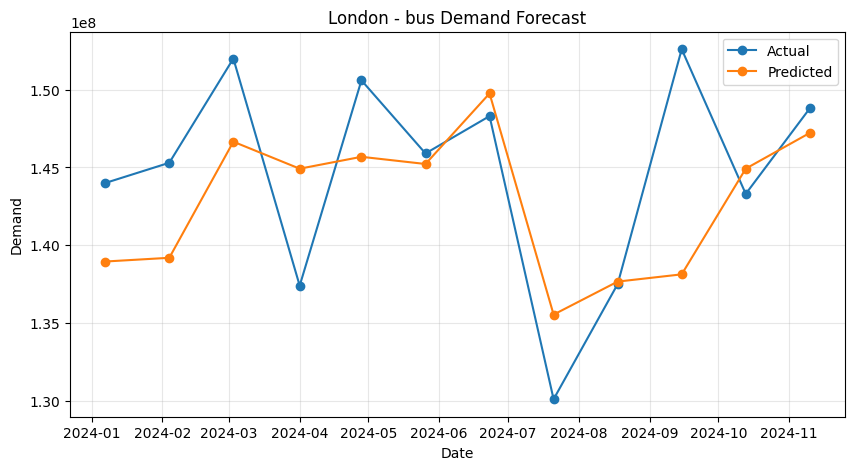

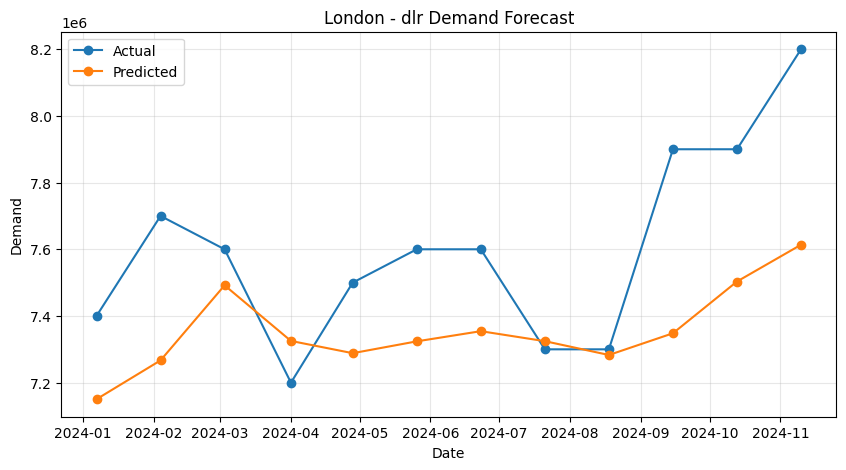

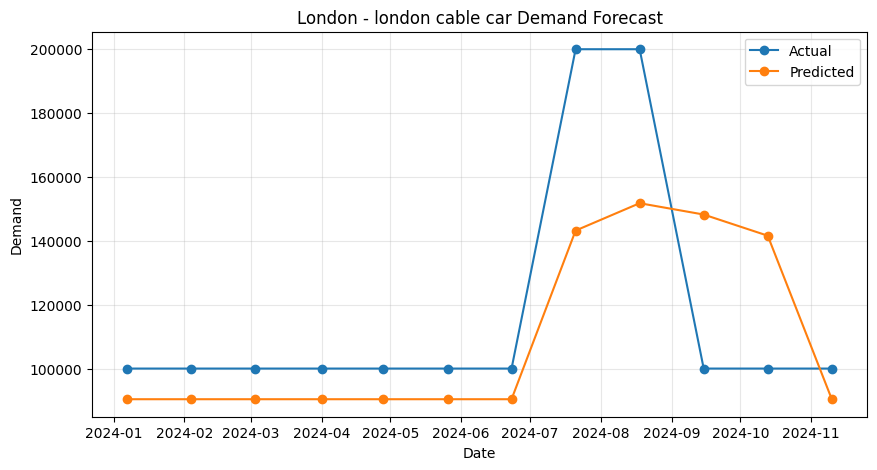

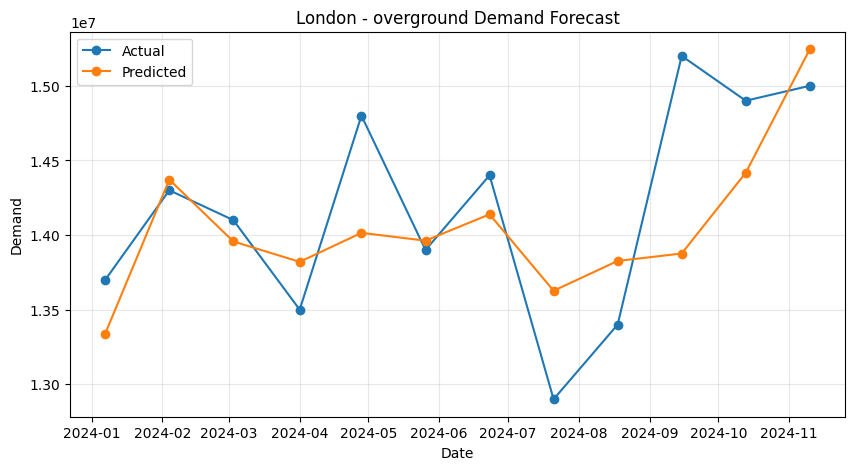

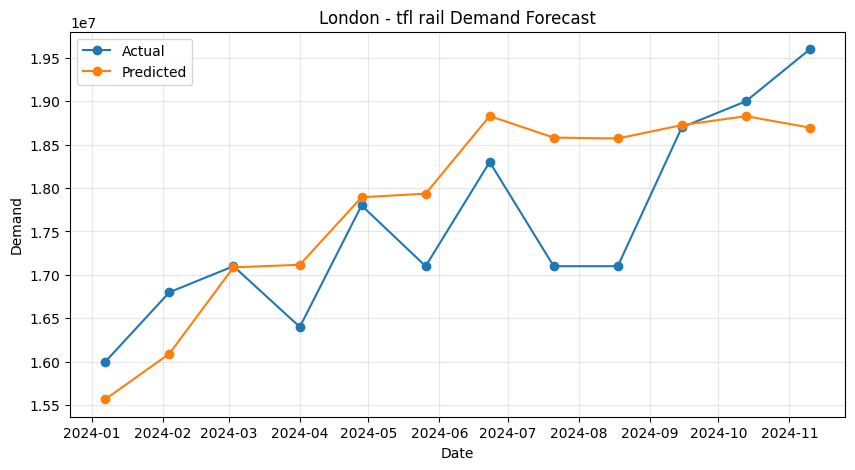

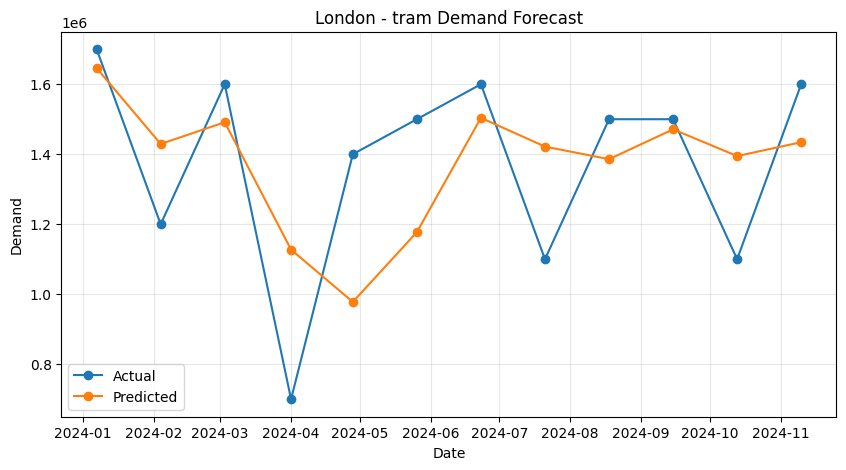

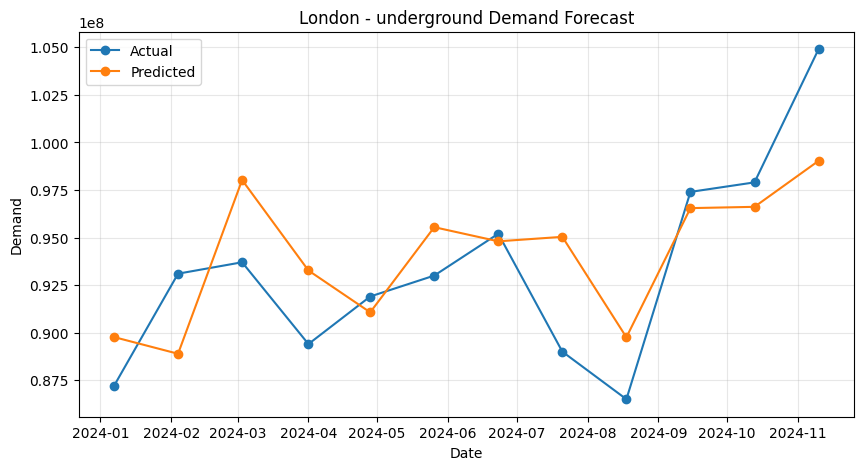

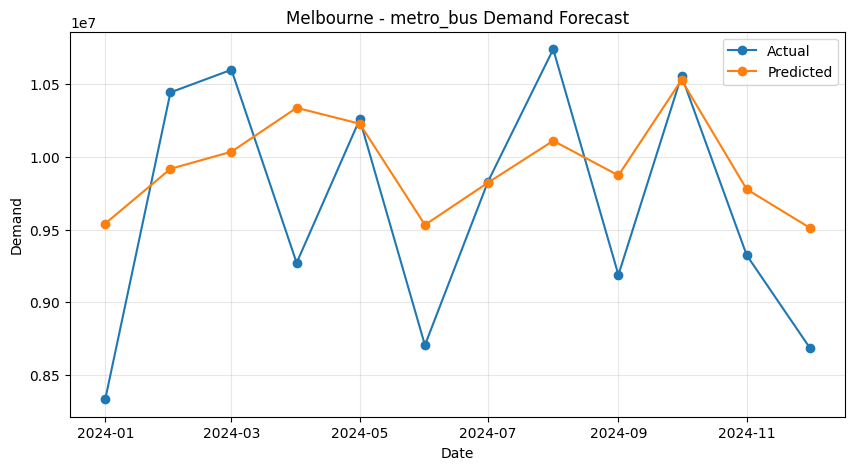

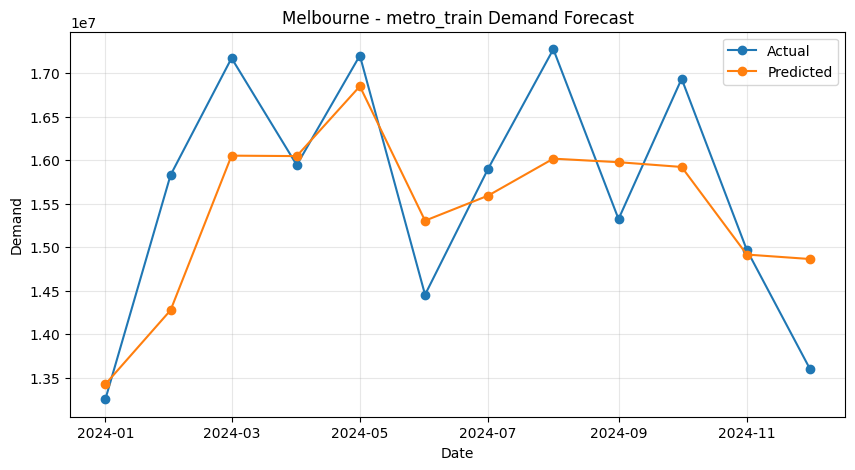

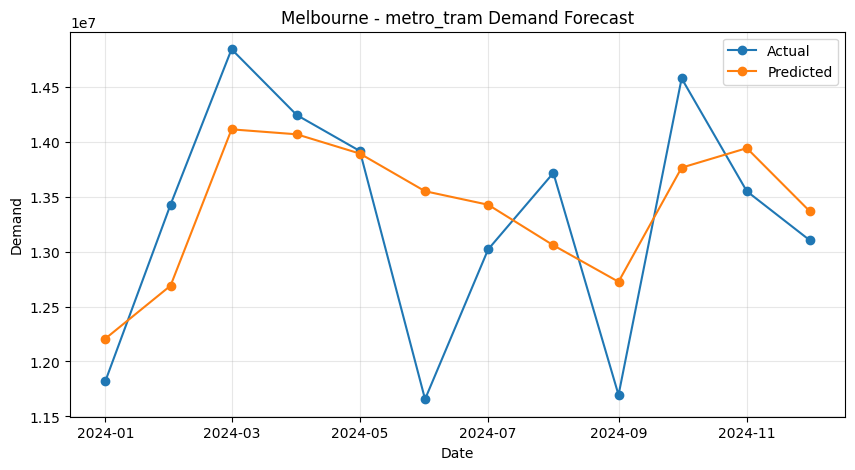

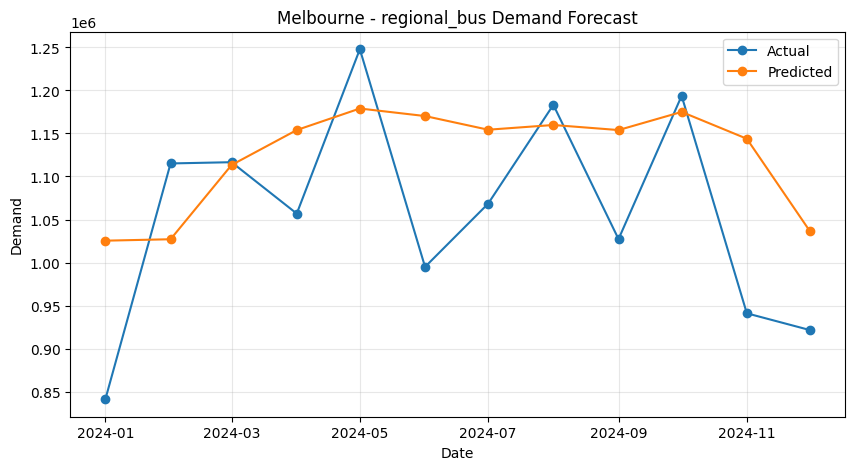

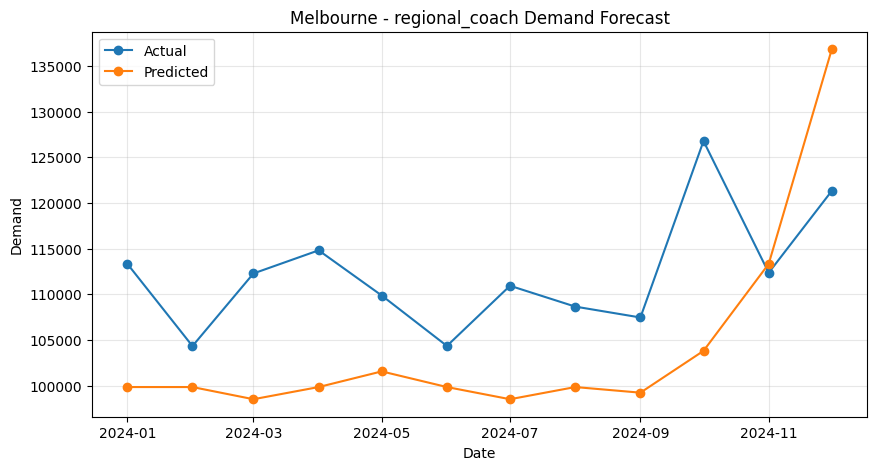

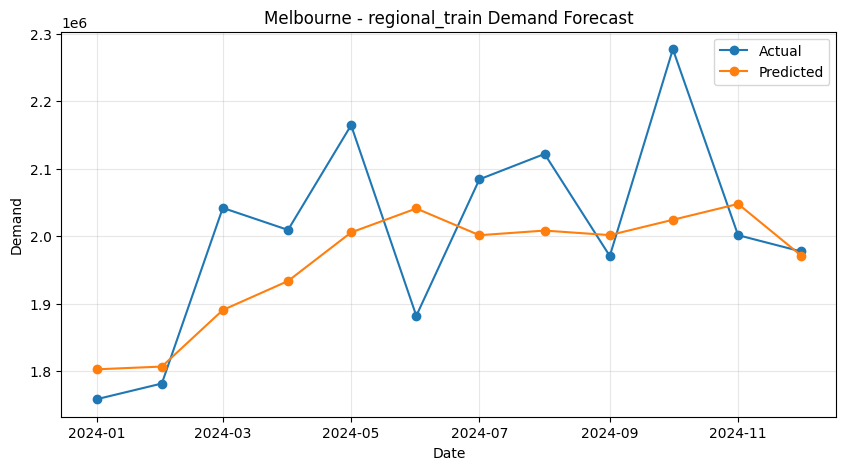

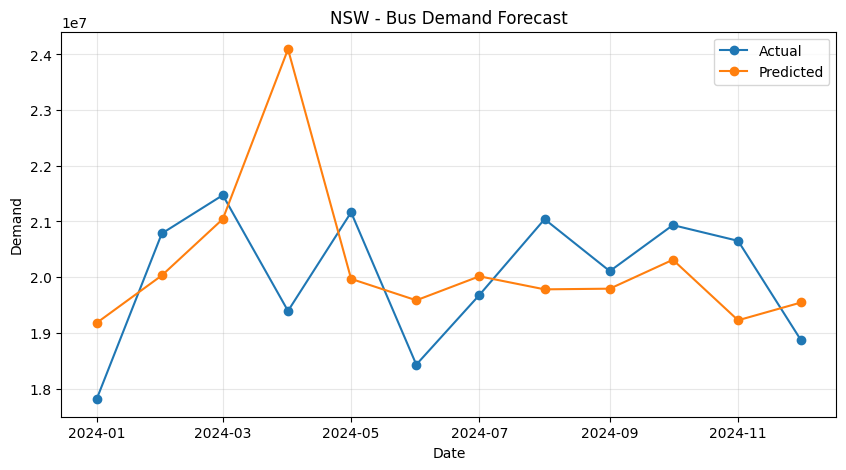

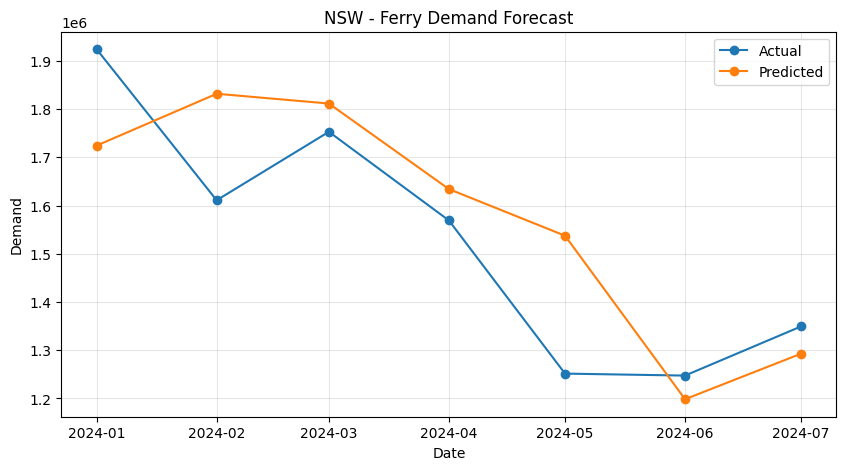

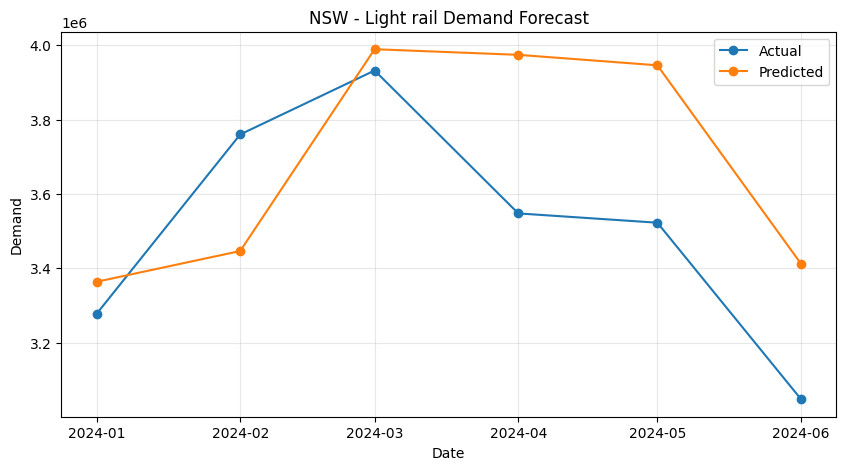

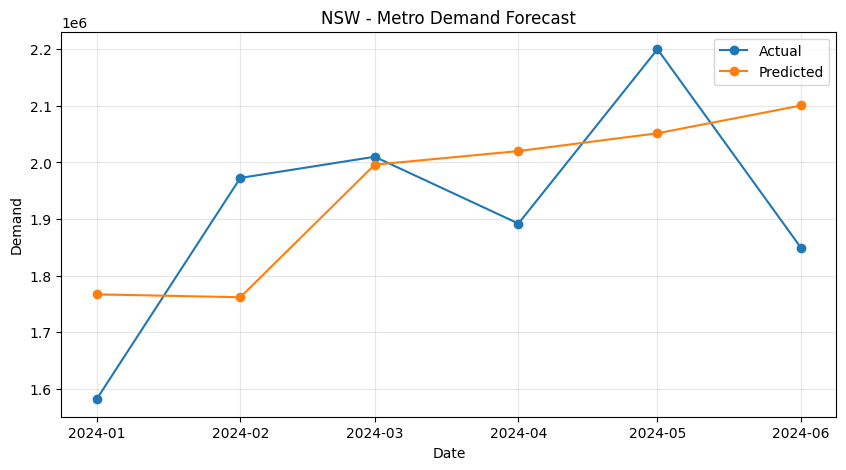

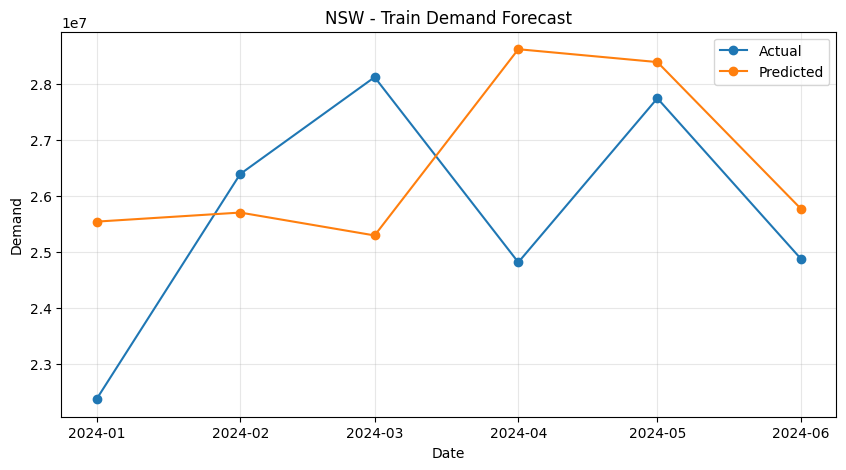

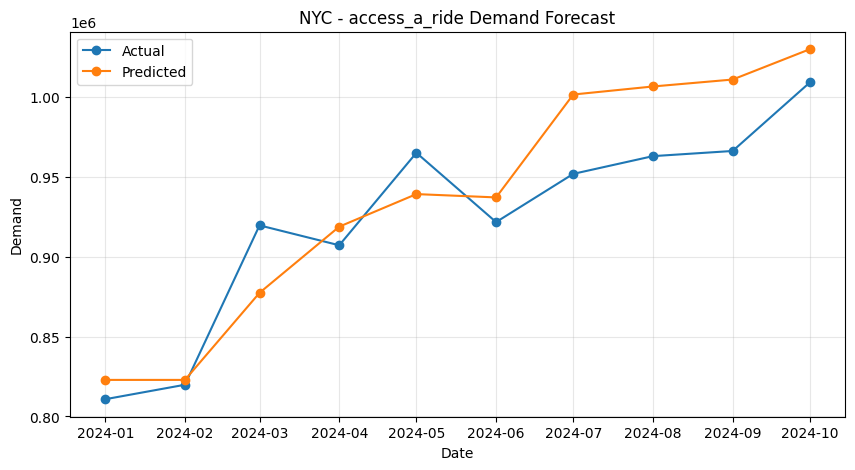

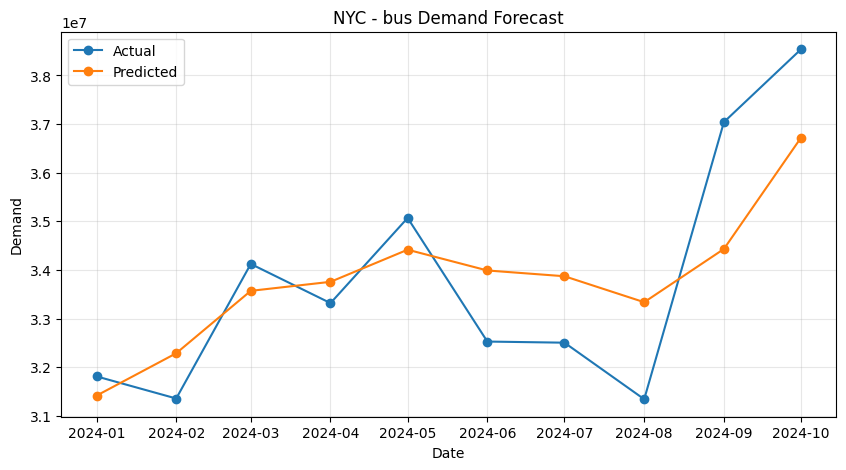

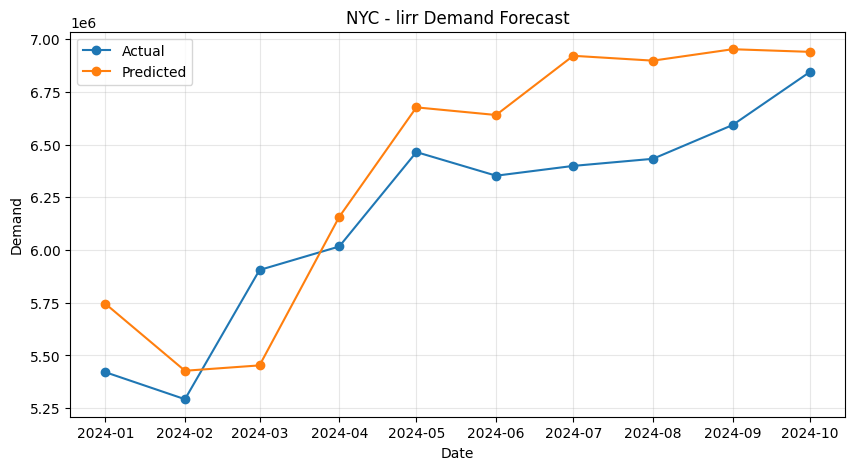

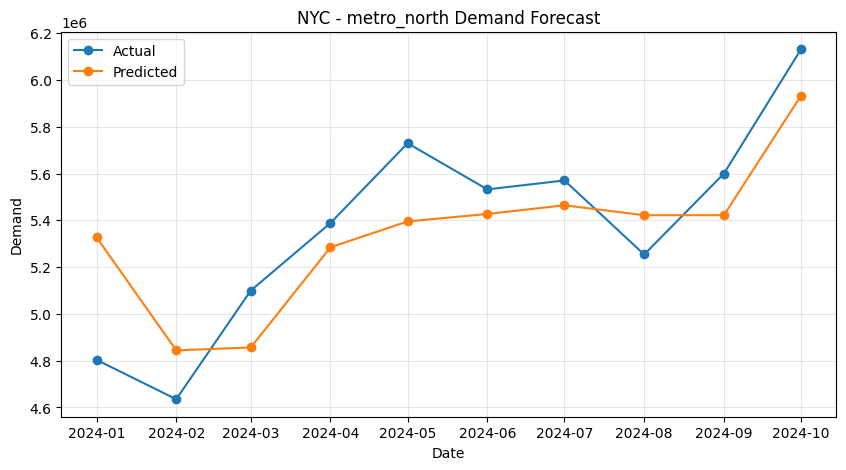

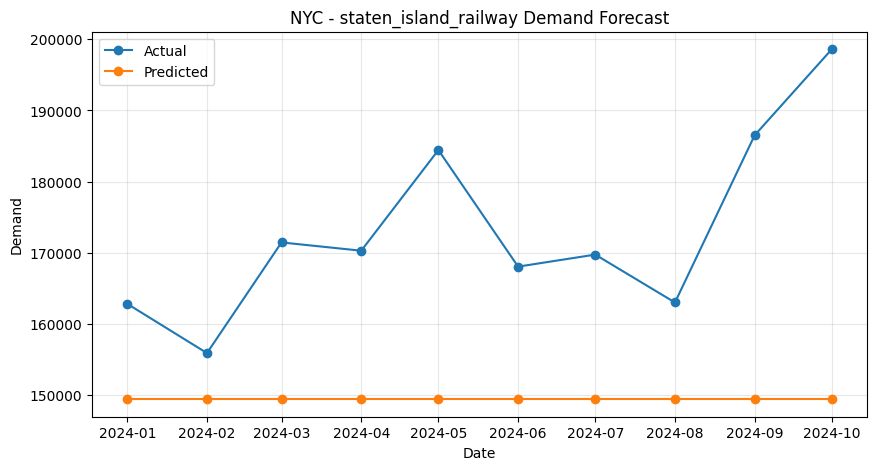

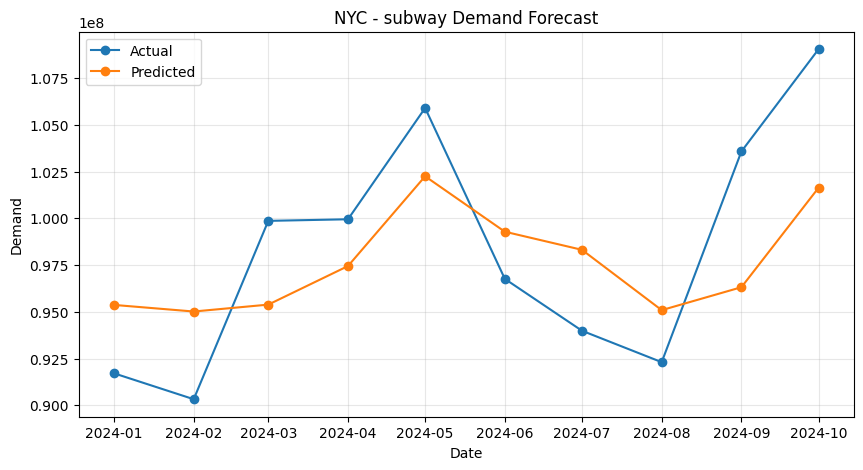

In [21]:
# ============================================================
# Plotting actual vs predicted by city-mode
# ============================================================

for (city, mode), temp in test_df.groupby(["city", "mode"]):
    if len(temp) < 2:
        continue

    plt.figure(figsize=(10, 5))
    plt.plot(temp["date"], temp["demand"], label="Actual", marker="o")
    plt.plot(temp["date"], temp["tuned_prediction"], label="Predicted", marker="o")
    plt.title(f"{city} - {mode} Demand Forecast")
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


These visualisations compare the actual passenger demand against the predicted demand generated by the forecasting model across multiple cities and transport modes. The blue line represents the real observed demand values, while the orange line represents the model’s predicted values.

**London Transport Forecasts**

The London visualisations demonstrate forecasting performance across multiple transport systems including buses, DLR, underground, trams, overground, TfL rail and cable car services.

- The model successfully captures the overall seasonal demand trends across most transport modes.
- Bus and underground demand show relatively strong forecasting performance, with predicted values closely following actual passenger trends.
- Overground and TfL rail forecasts also demonstrate good alignment, especially during stable demand periods.
- The cable car forecast shows larger fluctuations because of the relatively small dataset and highly irregular demand behaviour.


**Melbourne Transport Forecasts**

The Melbourne visualisations include metro trains, trams, buses and regional transport systems.

- The model captures the cyclical monthly trends reasonably well across all Melbourne transport modes.
- Metro train and metro tram forecasts show relatively accurate trend following, especially during mid-year demand increases.
- Regional transport modes display more variability because of lower passenger volumes and irregular travel behaviour.
- The forecasting model performs better during stable periods and slightly struggles during sudden spikes or drops in demand.

Overall, the model demonstrates strong capability in modelling temporal transport demand patterns.


**NSW Transport Forecasts**

The NSW visualisations show forecasts for buses, ferries, light rail, metro and train systems.

- Bus and train demand forecasts successfully capture medium-term demand movement patterns.
- Metro and light rail predictions remain relatively smooth and stable, indicating the model learned broader temporal behaviour rather than short-term fluctuations.
- Ferry demand demonstrates higher volatility due to smaller ridership values and limited available observations.

The model generally performs well in maintaining overall trend direction across transport modes.


**NYC Transport Forecasts**

The NYC visualisations include subway systems, buses, LIRR, Metro-North, Access-A-Ride and Staten Island Railway.

- Subway and bus forecasts show good alignment with actual demand patterns, particularly during periods of gradual demand growth.
- LIRR and Metro-North forecasts successfully model steady increases in ridership over time.
- Staten Island Railway forecasts appear flatter because the model smooths smaller-scale fluctuations.
The forecasting system effectively captures long-term transport demand behaviour despite variations between different transport systems.

# LSTM Model

The LSTM uses normalised demand_index values instead of raw demand because raw demand scales differ greatly across cities and modes. Considering the available data is monthly and relatively small, so the LSTM is an experimental component. The tuned Random Forest model is the stronger practical benchmark.


In [22]:
# LSTM model 
lstm_data = aligned[[
    "date",
    "city",
    "mode",
    "demand_index"
]].copy()

# Sorting by series and time
lstm_data = lstm_data.sort_values(["city", "mode", "date"])

# Creating one identifier per city-mode time series
lstm_data["series_id"] = lstm_data["city"] + "_" + lstm_data["mode"].astype(str)

display(lstm_data.head())
print(lstm_data.shape)


,date,city,mode,demand_index,series_id
132,2020-05-31,London,bus,0.387339,London_bus
133,2020-06-28,London,bus,0.549692,London_bus
134,2020-07-26,London,bus,0.619743,London_bus
135,2020-08-23,London,bus,0.781272,London_bus
136,2020-09-20,London,bus,0.840609,London_bus


(1301, 5)


### Creating LSTM Sequences

LSTM models need sequence input. This section converts each city-mode time series into supervised learning sequences.

For example, with a sequence length of 6:
- input = previous 6 months of demand index  
- output = next month demand index  


In [23]:
# Creating LSTM sequences
def create_lstm_sequences(data, sequence_length=6):
    """
    Create LSTM sequences from each city-mode series.

    Parameters
    ----------
    data : pandas.DataFrame
        Data containing date, series_id and demand_index.

    sequence_length : int
        Number of previous time steps used to predict the next value.

    Returns
    -------
    X_seq : numpy.ndarray
        Sequence input with shape (samples, timesteps, features).

    y_seq : numpy.ndarray
        Target values.

    meta : pandas.DataFrame
        Metadata containing series_id and target date for each sample.
    """

    X_seq = []
    y_seq = []
    meta = []

    # Creating sequences separately for each city-mode series
    for series_id, group in data.groupby("series_id"):
        group = group.sort_values("date").copy()
        values = group["demand_index"].values
        dates = group["date"].values

        # Skipping very short series
        if len(values) <= sequence_length:
            continue

        # Sliding window sequence creation
        for i in range(sequence_length, len(values)):
            X_seq.append(values[i-sequence_length:i])
            y_seq.append(values[i])
            meta.append({
                "series_id": series_id,
                "date": dates[i]
            })

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    meta = pd.DataFrame(meta)

    if len(X_seq) == 0:
        raise ValueError("No LSTM sequences created. Reduce sequence length or check data length.")

    # LSTM expects 3D input: samples, timesteps, features
    X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))

    return X_seq, y_seq, meta


SEQUENCE_LENGTH = 6

X_lstm, y_lstm, lstm_meta = create_lstm_sequences(
    lstm_data,
    sequence_length=SEQUENCE_LENGTH
)

print("LSTM X shape:", X_lstm.shape)
print("LSTM y shape:", y_lstm.shape)
display(lstm_meta.head())


LSTM X shape: (1157, 6, 1)
LSTM y shape: (1157,)


,series_id,date
0,London_bus,2020-11-15
1,London_bus,2020-12-13
2,London_bus,2021-01-10
3,London_bus,2021-02-07
4,London_bus,2021-03-07


### Splitting LSTM Data

The LSTM uses the same test split as the Random Forest model.
Samples before 2024 are used for training, while samples from 2024 onward are used for testing.


In [24]:
# Train/test split for LSTM
lstm_meta["date"] = pd.to_datetime(lstm_meta["date"])

train_idx = lstm_meta["date"] < SPLIT_DATE
test_idx = lstm_meta["date"] >= SPLIT_DATE

X_lstm_train = X_lstm[train_idx.values]
y_lstm_train = y_lstm[train_idx.values]

X_lstm_test = X_lstm[test_idx.values]
y_lstm_test = y_lstm[test_idx.values]

lstm_test_meta = lstm_meta[test_idx].copy()

print("LSTM train shape:", X_lstm_train.shape)
print("LSTM test shape:", X_lstm_test.shape)


LSTM train shape: (904, 6, 1)
LSTM test shape: (253, 6, 1)


### Training Experimental LSTM

This section trains a small LSTM model. The model architecture is intentionally simple because the dataset is monthly and relatively small. 


In [25]:
# Building and training LSTM
# Defining small LSTM architecture
lstm_model = Sequential([
    LSTM(32, input_shape=(SEQUENCE_LENGTH, 1), return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

# Compiling model
lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Early stopping reduces overfitting
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Training model
history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_split=0.2,
    epochs=100,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

# Predicting test sequences
lstm_pred = lstm_model.predict(X_lstm_test).flatten()

# Evaluating LSTM on normalised demand index
lstm_results = evaluate_regression(
    y_lstm_test,
    lstm_pred,
    "Experimental LSTM on Demand Index"
)

# Saving prediction output
lstm_output = lstm_test_meta.copy()
lstm_output["actual_demand_index"] = y_lstm_test
lstm_output["predicted_demand_index"] = lstm_pred

display(lstm_output.head())


Epoch 1/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1933 - mae: 0.3199 - val_loss: 0.0169 - val_mae: 0.1098
Epoch 2/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0631 - mae: 0.1844 - val_loss: 0.0124 - val_mae: 0.0905
Epoch 3/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0620 - mae: 0.1870 - val_loss: 0.0179 - val_mae: 0.1134
Epoch 4/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0588 - mae: 0.1783 - val_loss: 0.0131 - val_mae: 0.0940
Epoch 5/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0563 - mae: 0.1722 - val_loss: 0.0147 - val_mae: 0.1006
Epoch 6/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0553 - mae: 0.1719 - val_loss: 0.0141 - val_mae: 0.0979
Epoch 7/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0516 - mae: 0.1640 - val_loss: 0.0112 - val_mae: 0.0838
Epoch 8/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0504 - mae: 0.1640 - val_loss: 0.0188 - val_mae: 0.1151
Epoch 9/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.053

,series_id,date,actual_demand_index,predicted_demand_index
41,London_bus,2024-01-07,1.186742,1.159749
42,London_bus,2024-02-04,1.197456,1.187548
43,London_bus,2024-03-03,1.252672,1.204259
44,London_bus,2024-04-01,1.132350,1.239656
45,London_bus,2024-04-28,1.241134,1.204080


### Plotting LSTM Training History

This plot shows training and validation loss across epochs. A large gap between training and validation loss would indicate overfitting.


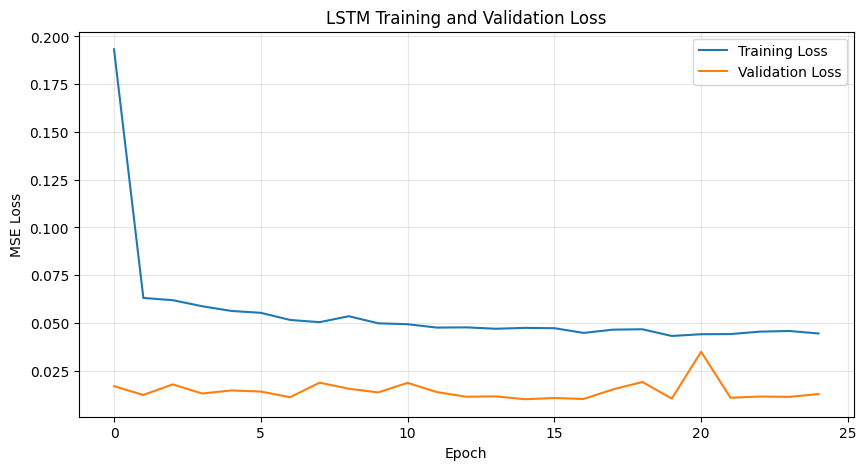

In [26]:
if "history" in globals():
    plt.figure(figsize=(10, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title("LSTM Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


The graph illustrates the training and validation loss of the LSTM model across multiple epochs during the transport demand forecasting process. Initially, the training loss starts at a high value, indicating that the model had poor predictions at the beginning of training. However, the loss decreases sharply within the first few epochs, showing that the LSTM quickly learned important temporal patterns and relationships within the transport demand data. As training progresses, both the training and validation loss curves stabilise, indicating that the model is converging effectively and learning consistent sequential behaviour. The validation loss remains relatively low and stable throughout the training process, suggesting that the model generalises well to unseen data and does not suffer from significant overfitting. Minor fluctuations in validation loss are present, which is expected in time-series forecasting due to variations and noise within real-world transport demand data. Overall, the graph demonstrates that the LSTM model successfully captured temporal demand patterns and achieved stable forecasting performance across the training process.

### Plotting LSTM Actual vs Predicted Demand Index

This scatter plot compares LSTM predicted values against actual demand-index values. Points close to the diagonal indicate better predictions.


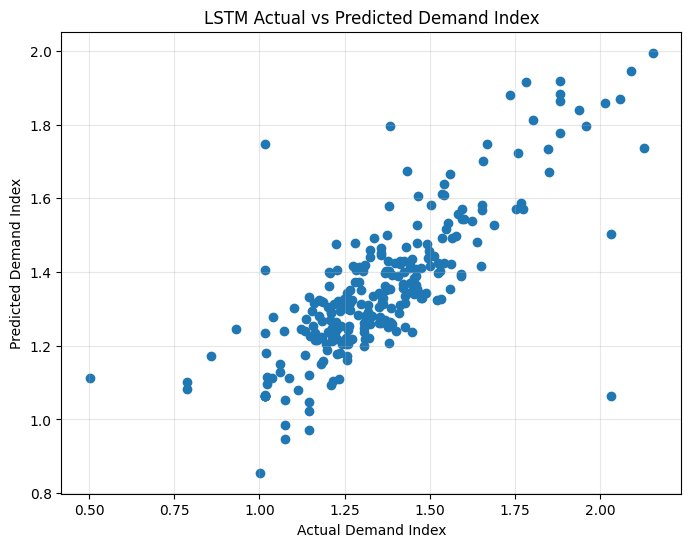

In [27]:
if "lstm_pred" in globals():
    plt.figure(figsize=(8, 6))
    plt.scatter(y_lstm_test, lstm_pred)
    plt.xlabel("Actual Demand Index")
    plt.ylabel("Predicted Demand Index")
    plt.title("LSTM Actual vs Predicted Demand Index")
    plt.grid(True, alpha=0.3)
    plt.show()


The scatter plot illustrates the relationship between the actual transport demand index values and the demand values predicted by the LSTM model. Each point on the graph represents a prediction made by the model, where the x-axis shows the actual demand index and the y-axis shows the corresponding predicted demand index. The points generally follow an upward diagonal trend, indicating a strong positive relationship between actual and predicted values. This suggests that the LSTM model was able to successfully capture the underlying temporal demand patterns and produce predictions that closely align with real transport demand behaviour. Most predictions are concentrated around the central region of the graph, showing that the model performs particularly well for moderate demand levels. While a few scattered points and outliers are present, which is expected in real-world forecasting tasks, the overall clustering pattern demonstrates that the model achieved reasonable forecasting accuracy and was effective in learning sequential transport demand dynamics from the dataset.

# Final Project Summary

This notebook builds a complete multi-city and multi-modal public transport demand forecasting pipeline.

## What was completed

- Loaded public transport demand datasets from London, NYC, Melbourne, Victoria and NSW  
- Standardised all datasets into a common time-series format  
- Added Melbourne day-type patronage enrichment features  
- Created temporal, lag and rolling demand features  
- Trained and evaluated a Random Forest forecasting model  
- Tuned the model using time-series cross-validation  
- Generated dynamic high-demand flags for scheduling support  
- Added an experimental LSTM model for the deep learning component  

## Key limitation

The available data is mostly monthly or aggregated, so deep learning models are limited by the small number of time steps. Therefore, the tuned Random Forest model should be treated as the main practical forecasting benchmark, while LSTM is included as an experimental extension.

## Future improvements

- Add weather and major event datasets  
- Reintroduce GTFS if a working local ZIP is available  
- Use station-level or route-level demand data  
- Build graph-based network features  
- Extend LSTM to multi-horizon forecasting  
